# Classification Track — Telco Customer Churn (Part A)
**23CSE301 Machine Learning Capstone — Review 1**

**Dataset:** `data/telco_churn.csv` — customer account, service, and billing attributes for a
telecom operator.
**Target:** `Churn` (Yes/No) — binary classification problem.

This notebook covers **Part A** (Review 1 scope): data audit, EDA, cleaning, feature engineering,
and the first 5 required classification algorithms (Logistic Regression, KNN, Naive Bayes,
Decision Tree, SVM) with their evaluation. Part B (Random Forest, AdaBoost, Gradient Boosting,
Bagging, MLP) and the consolidated 10-algorithm comparison are completed for **Review 2**.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import joblib
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay
)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 100


## Section A — Dataset Loading & Audit

In [2]:
df = pd.read_csv(r"../data/telco_churn.csv")
print('Shape:', df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.dtypes


customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [4]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing = df.isnull().sum()
missing_report = pd.DataFrame({'missing_count': missing, 'missing_pct': (missing/len(df)*100).round(2)})
missing_report[missing_report['missing_count'] > 0]


,missing_count,missing_pct
TotalCharges,11,0.16


In [5]:
print(df['Churn'].value_counts())
print((df['Churn'].value_counts(normalize=True) * 100).round(2))


Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


**Observation:** 7,043 customers, 21 columns. The target `Churn` is binary (Yes/No) and
**imbalanced** (~26.5% churn vs ~73.5% retained) — this motivates using a **stratified**
train/test split and weighted F1 / ROC-AUC rather than plain accuracy alone. `TotalCharges` had a
small number of blank entries corresponding to customers with `tenure = 0` (brand-new sign-ups who
haven't been billed yet) — a real, explainable data-quality quirk rather than random missingness.

## Section A2 — Exploratory Data Analysis

In [6]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = [c for c in df.columns if c not in num_cols + ['customerID', 'Churn']]
print('Numeric:', num_cols)
print('Categorical:', len(cat_cols), 'columns')

Numeric: ['tenure', 'MonthlyCharges', 'TotalCharges']
Categorical: 16 columns


The rubric asks for a distribution plot of **every** feature. Telco has 3 numeric columns and
16 categorical columns — both groups are plotted below.

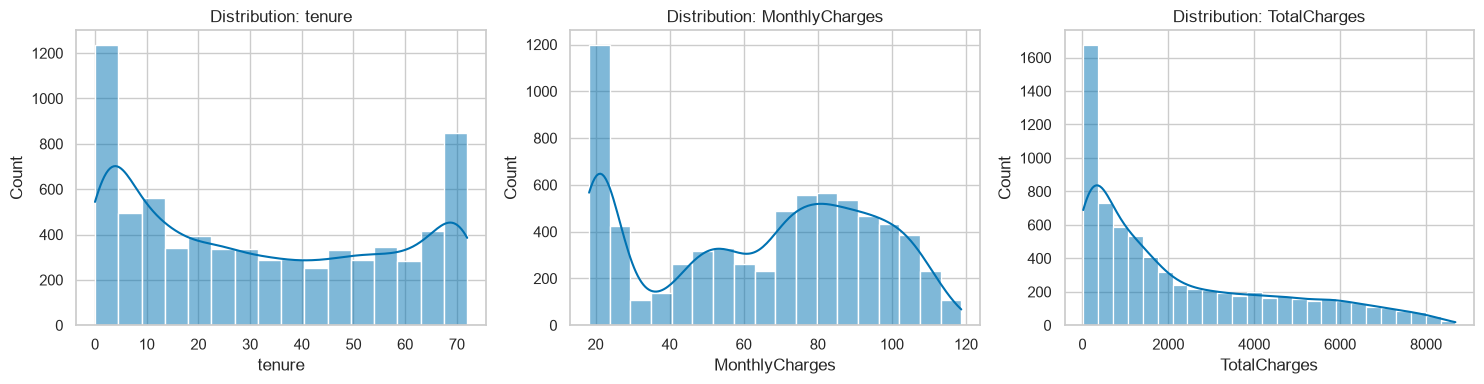

In [7]:
# Distribution plots — numeric features
fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax, color='#0072B2')
    ax.set_title(f'Distribution: {col}')
plt.tight_layout()
plt.show()

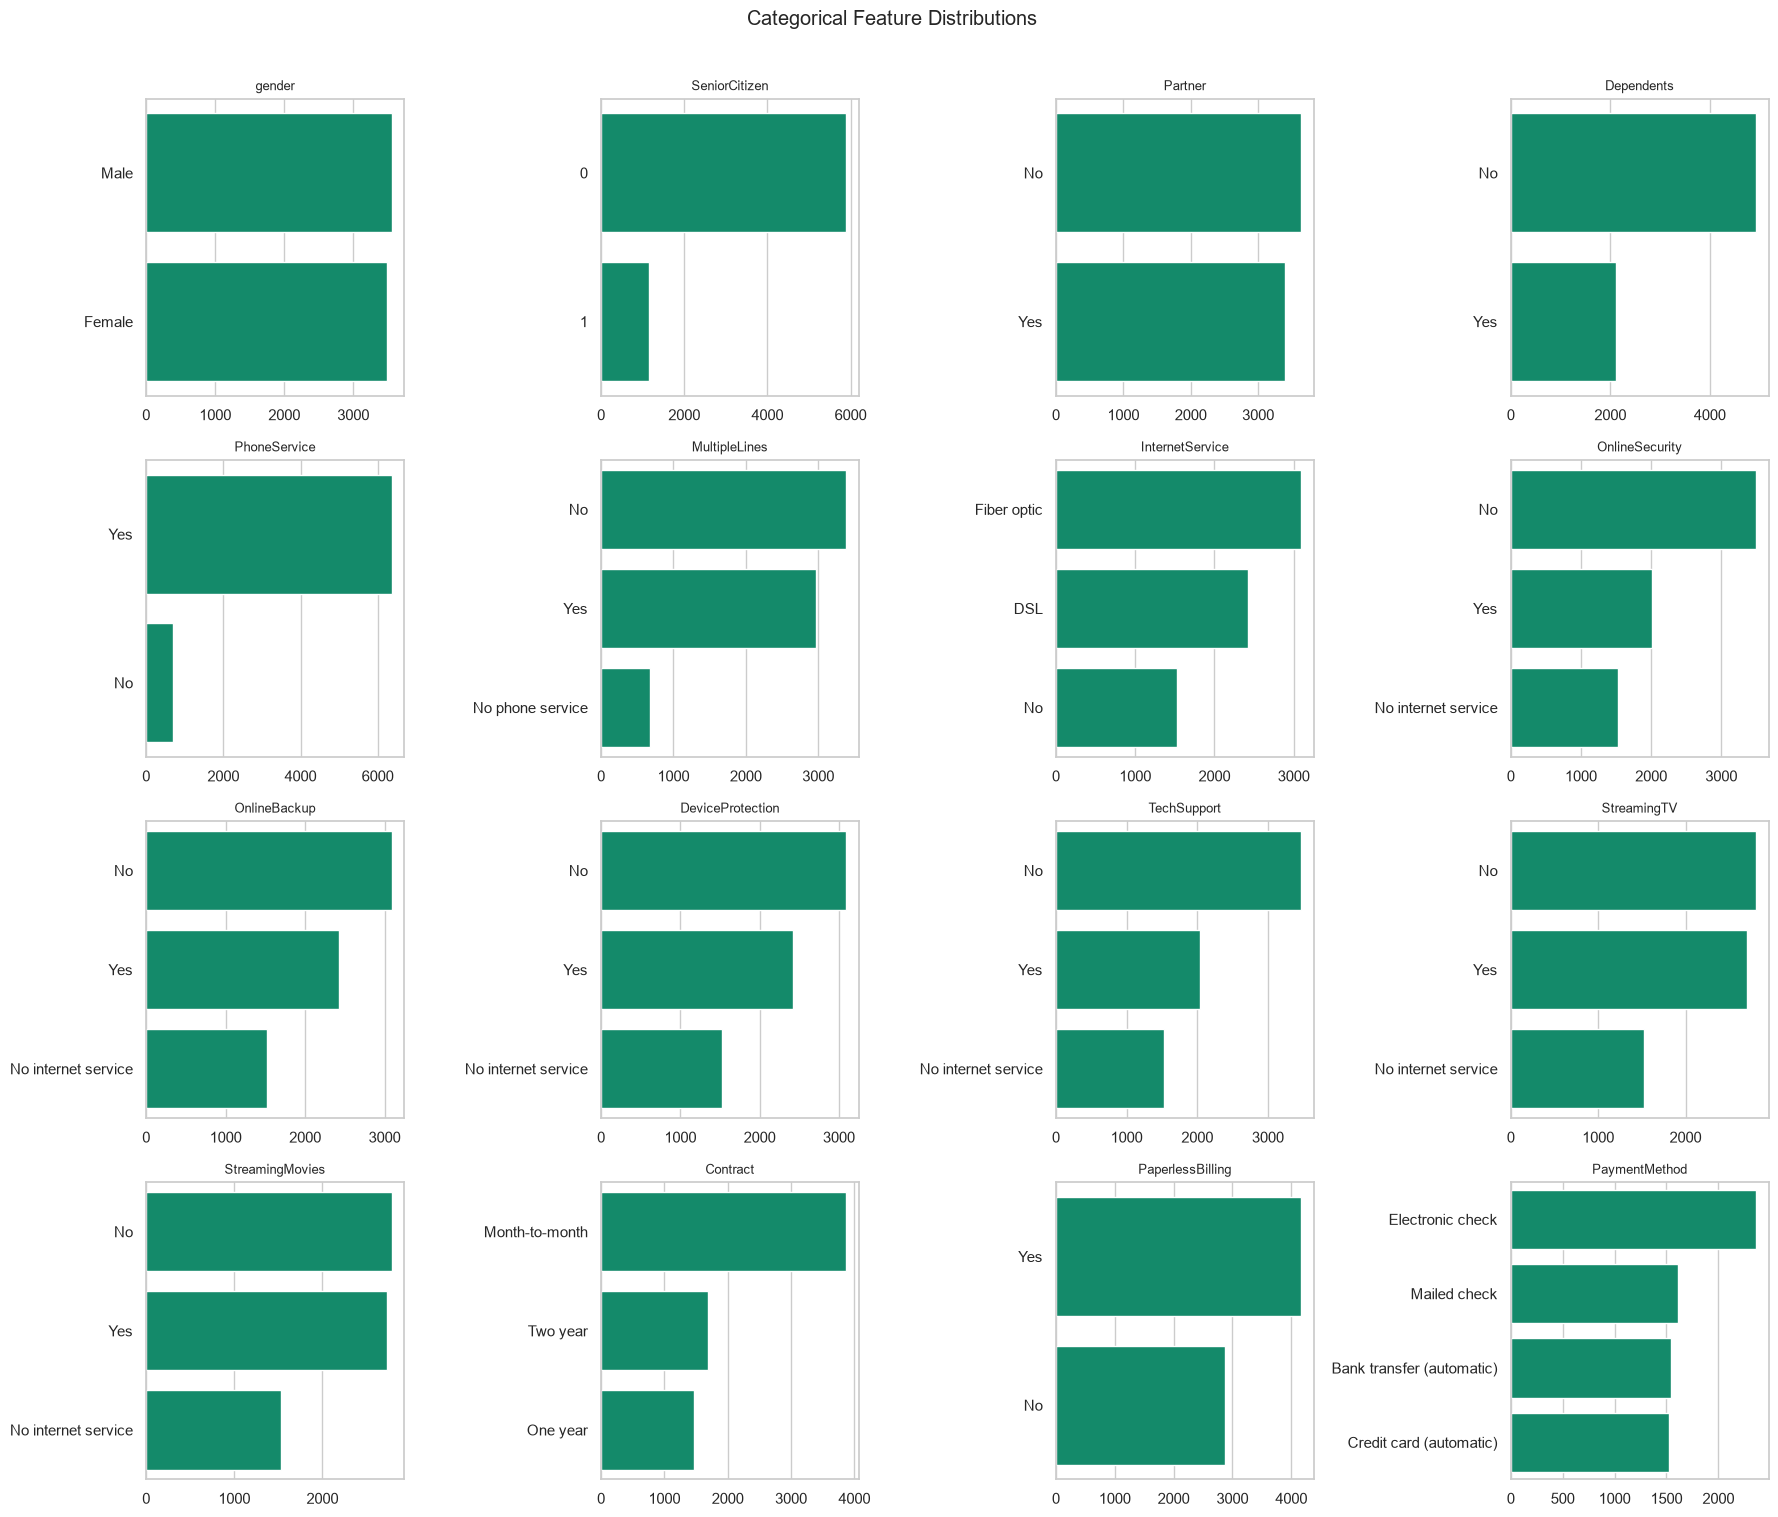

In [8]:
# Distribution plots — every categorical feature (count plots)
fig, axes = plt.subplots(4, 4, figsize=(18, 15))
for ax, col in zip(axes.flatten(), cat_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, color='#009E73')
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')
for ax in axes.flatten()[len(cat_cols):]:
    ax.axis('off')
plt.suptitle('Categorical Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

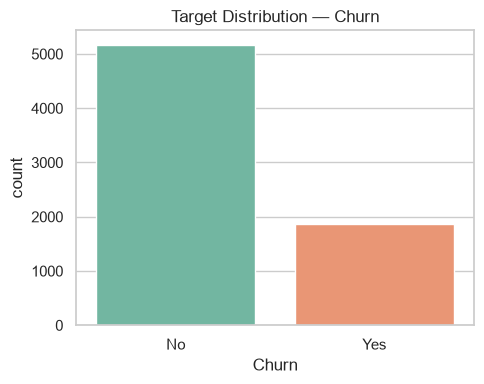

In [9]:
# Target distribution
plt.figure(figsize=(5,4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Target Distribution — Churn')
plt.tight_layout()
plt.show()

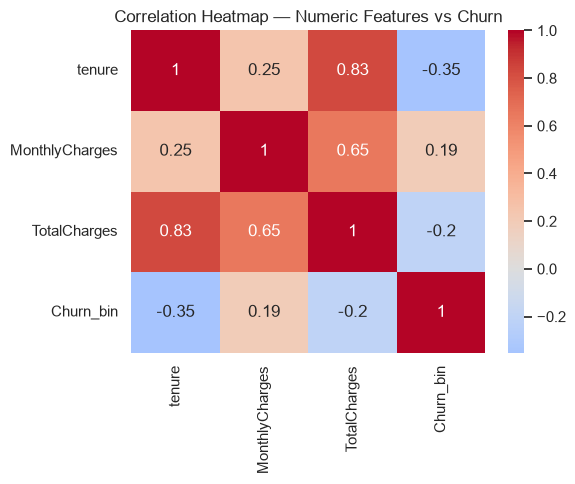

In [10]:
# Correlation heatmap (numeric features + binary-encoded target)
corr_df = df[num_cols].copy()
corr_df['Churn_bin'] = (df['Churn'] == 'Yes').astype(int)
plt.figure(figsize=(6,5))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numeric Features vs Churn')
plt.tight_layout()
plt.show()


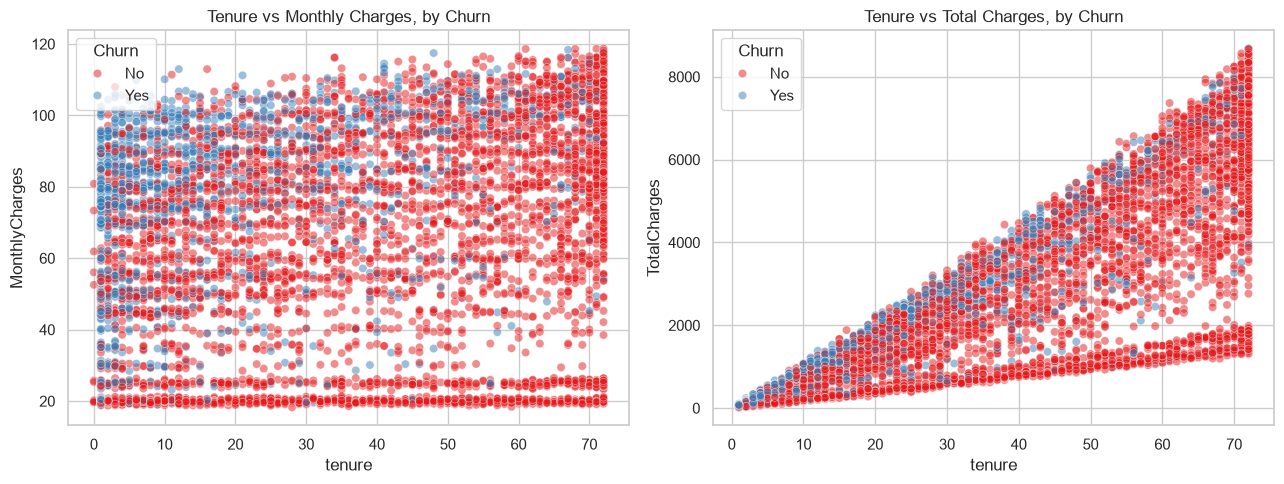

In [11]:
# Scatter plots: feature vs target relationship (at least 2)
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df, alpha=0.5, ax=axes[0], palette='Set1')
axes[0].set_title('Tenure vs Monthly Charges, by Churn')

sns.scatterplot(x='tenure', y='TotalCharges', hue='Churn', data=df, alpha=0.5, ax=axes[1], palette='Set1')
axes[1].set_title('Tenure vs Total Charges, by Churn')
plt.tight_layout()
plt.show()

**Observations (check each against the actual plots above before repeating them anywhere —
these are starting points, not settled conclusions):**
- The `tenure` histogram shows a spike near 0 and another mass near the top of the range — worth
  describing in your own words as "many customers are either very new or very long-tenured" if
  that's what you see in your run, rather than assuming a specific textbook shape.
- The correlation heatmap gives a numeric read on the direction and rough strength of the
  relationship between `tenure`, `MonthlyCharges`, `TotalCharges`, and churn — read the actual sign
  and magnitude off the heatmap rather than restating a general assumption about telecom churn.
- The two scatter plots colour points by `Churn`; look at where the two colours separate (or don't)
  along the tenure axis in your own output before describing the pattern.
- The categorical count plots show which service/contract categories are more or less common —
  note any category that stands out as unusually rare or dominant, since that can affect how much a
  classifier can learn about it.
- Because of what these plots show, `tenure` is a reasonable candidate to matter to the classifiers
  below — but treat that as a hypothesis the model results should confirm, not a foregone
  conclusion.

## Section B — Preprocessing & Feature Engineering

**B1. Data cleaning.**

In [12]:
print('Duplicate rows:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

# Impute the small number of missing TotalCharges (brand-new customers, tenure=0) with 0,
# which is the factually correct value (they have not been billed yet), not just a statistical fill.
df['TotalCharges'] = df.loc[df['tenure'] == 0, 'TotalCharges'].fillna(0)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())
print('Remaining nulls:', df.isnull().sum().sum())


Duplicate rows: 0
Remaining nulls: 0


In [13]:
# Outlier check on numeric columns via IQR (report only)
for col in num_cols:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'{col}: {n_out} potential outliers (IQR rule)')


tenure: 0 potential outliers (IQR rule)
MonthlyCharges: 0 potential outliers (IQR rule)
TotalCharges: 0 potential outliers (IQR rule)


No extreme outliers requiring removal were found — billing/tenure values are naturally bounded
and business-plausible. **B2/B3: encoding, scaling, feature engineering, and the stratified split**
are done next.

In [14]:
service_cols = ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

def count_services(row):
    return sum(1 for c in service_cols if row[c] not in ['No', 'No internet service', 'No phone service'])

df['NumServices'] = df.apply(count_services, axis=1)
cat_cols_final = cat_cols + []  # NumServices is numeric, added to num_features below
num_cols_final = num_cols + ['NumServices']
print(df[['NumServices']].describe())


       NumServices
count  7043.000000
mean      4.146244
std       2.312720
min       1.000000
25%       2.000000
50%       4.000000
75%       6.000000
max       9.000000

In [15]:
target = 'Churn'
feature_cols = [c for c in df.columns if c not in ['customerID', target]]
num_features = [c for c in num_cols_final]
cat_features = [c for c in feature_cols if c not in num_features]

X = df[feature_cols]
y = (df[target] == 'Yes').astype(int)   # 1 = churned, 0 = retained

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Train churn rate:', y_train.mean().round(3), '| Test churn rate:', y_test.mean().round(3))

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
])


Train: (5634, 20)  Test: (1409, 20)
Train churn rate: 0.265 | Test churn rate: 0.265


## Section C — Classification Track, Part A (5 Algorithms)

Part B algorithms (Random Forest, AdaBoost, Gradient Boosting, Bagging, MLP) and the final
consolidated 10-algorithm table follow in Review 2, on this same train/test split.

In [16]:
models_partA = {
    '1. Logistic Regression': LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    '2. K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=11),
    '3. Naive Bayes (Gaussian)': GaussianNB(),
    '4. Decision Tree Classifier': DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    '5. Support Vector Machine (SVC)': SVC(C=1.0, kernel='rbf', probability=True, random_state=RANDOM_STATE),
}


In [17]:
results = []
fitted_pipelines = {}
roc_data = {}

for name, estimator in models_partA.items():
    pipe = Pipeline([('prep', preprocessor), ('model', estimator)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')
    auc = roc_auc_score(y_test, proba)

    results.append({'Algorithm': name, 'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1 (weighted)': f1, 'ROC-AUC': auc})
    fitted_pipelines[name] = pipe
    roc_data[name] = (y_test, proba)

results_df = pd.DataFrame(results).sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
results_df


  File "C:\Users\manas\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\manas\AppData\Local\Programs\Python\Python311\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\manas\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\manas\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\manas\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.Crea

,Algorithm,Accuracy,Precision,Recall,F1 (weighted),ROC-AUC
0,1. Logistic Regression,0.797729,0.789979,0.797729,0.792541,0.839084
1,5. Support Vector Machine (SVC),0.794180,0.782800,0.794180,0.784916,0.795916
2,4. Decision Tree Classifier,0.794890,0.782638,0.794890,0.783927,0.834909
3,2. K-Nearest Neighbors,0.772889,0.769520,0.772889,0.771067,0.811211
4,3. Naive Bayes (Gaussian),0.687012,0.792759,0.687012,0.705282,0.805203


**D2. Preliminary comparison table** (ranked by weighted F1):

In [18]:
results_df.style.format({
    'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
    'F1 (weighted)': '{:.4f}', 'ROC-AUC': '{:.4f}'
}).background_gradient(subset=['F1 (weighted)'], cmap='Greens')


,Algorithm,Accuracy,Precision,Recall,F1 (weighted),ROC-AUC
0,1. Logistic Regression,0.7977,0.7900,0.7977,0.7925,0.8391
1,5. Support Vector Machine (SVC),0.7942,0.7828,0.7942,0.7849,0.7959
2,4. Decision Tree Classifier,0.7949,0.7826,0.7949,0.7839,0.8349
3,2. K-Nearest Neighbors,0.7729,0.7695,0.7729,0.7711,0.8112
4,3. Naive Bayes (Gaussian),0.6870,0.7928,0.6870,0.7053,0.8052


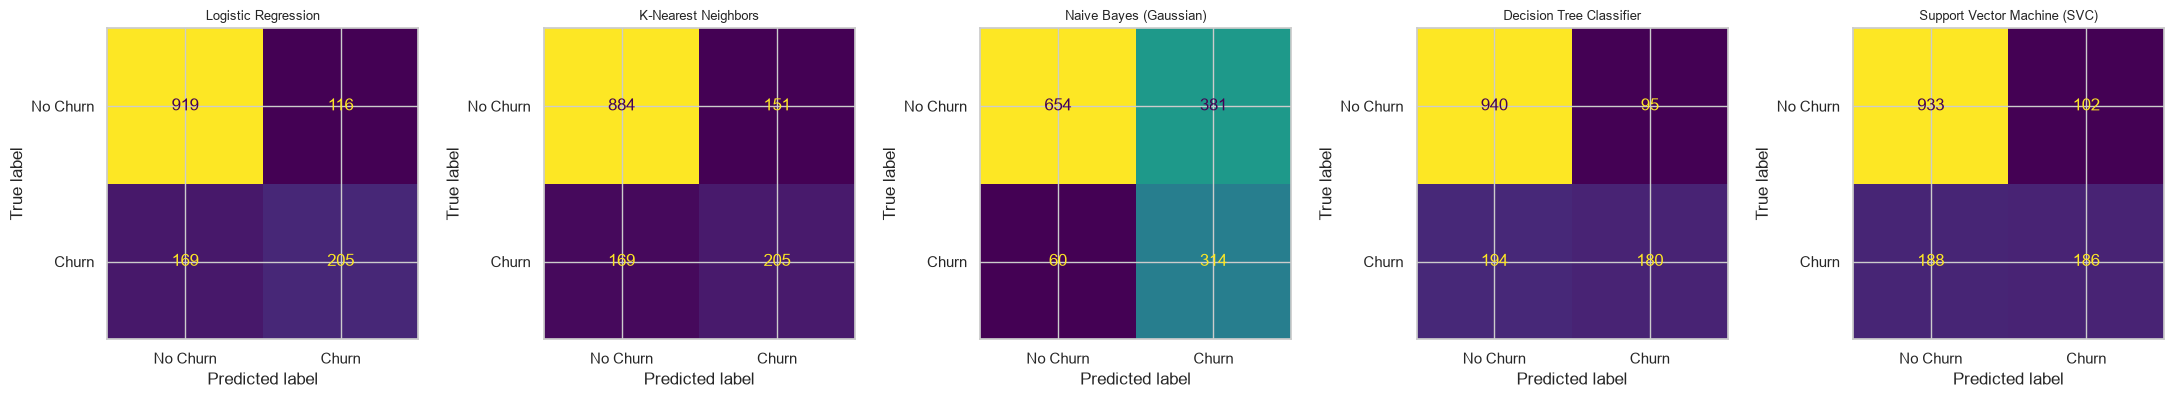

In [19]:
# Confusion matrix for every Part-A algorithm
fig, axes = plt.subplots(1, 5, figsize=(22,4))
for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    preds = pipe.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn']).plot(ax=ax, colorbar=False)
    ax.set_title(name.split('. ')[1], fontsize=9)
plt.tight_layout()
plt.show()


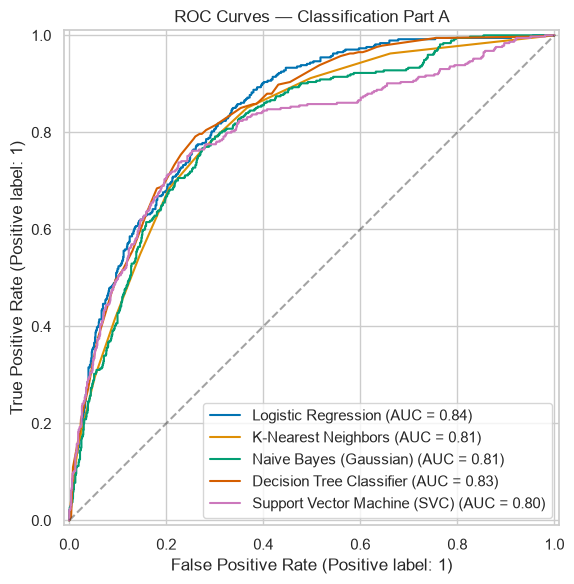

In [20]:
# ROC curves for all Part-A algorithms
plt.figure(figsize=(7,6))
for name, (yt, proba) in roc_data.items():
    RocCurveDisplay.from_predictions(yt, proba, name=name.split('. ')[1], ax=plt.gca())
plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.title('ROC Curves — Classification Part A')
plt.tight_layout()
plt.show()


**Reading the results:** compare the actual ranked table, confusion matrices, and ROC curves above
for your run — don't assume in advance which of the 5 algorithms will come out on top. A reasonable
way to explain the ranking at the viva is to look at what each confusion matrix gets wrong (e.g.
does it miss more churners, or wrongly flag more retained customers as churners?) and connect that
back to how the algorithm works, rather than reciting a generic expectation. All five models are
evaluated with **weighted F1 and ROC-AUC** (not just accuracy) specifically because of the
~26%/74% class imbalance measured in Section A — a model that just predicts the majority class
("No churn") would score high on accuracy alone without being useful, so don't lean on accuracy as
the headline number when you present this.

**Also be ready to explain, using your own actual split output:** why `stratify=y` was used for
this split but not for the regression track's split (Section B) — because `Churn` is a categorical
target with a measured class imbalance to preserve across train/test, whereas the regression
target is continuous and has no "classes" to stratify by.

**Next (Review 2):** Part B algorithms are added to this same pipeline/split, and the two model
sets are merged into the single consolidated 10-algorithm comparison table required by the
Review-2 rubric (Section A2).

## Saving the best Part A model
We persist the full fitted pipeline (preprocessing + model) of the top-ranked
Part A algorithm by weighted F1, so it can be reloaded later without retraining —
e.g. for the optional GUI/deployment bonus in Review 2.


In [21]:
os.makedirs('../models', exist_ok=True)

best_model_name = results_df.iloc[0]['Algorithm']
best_pipeline = fitted_pipelines[best_model_name]
joblib.dump(best_pipeline, '../models/classification_best_partA.pkl')
print(f"Saved best Part A model: {best_model_name} -> models/classification_best_partA.pkl")

results_df.to_csv('../models/classification_partA_results.csv', index=False)

reloaded = joblib.load('../models/classification_best_partA.pkl')
test_pred = reloaded.predict(X_test.iloc[:5])
print("Reload check passed:", test_pred)


Saved best Part A model: 1. Logistic Regression -> models/classification_best_partA.pkl
Reload check passed: [0 1 0 0 0]
